# 06h — Behavioral-structure metrics on the G=28 cohort (local disorganisation / perseveration)

Kickoff **G** of the E→G→F arc (`.claude/plans/coordination-EFG-roadmap.md`); the
recallable runner for **`RESULTS_HANDOFF §16`**. E's §15 order-shuffle-null found **0/15**
order signals — *global* symbol order carries no group signal beyond frequency. G tests the
**orthogonal** hypothesis: *local* execution structure (fragmentation, perseveration,
transition entropy, temporal drift) that the frequency histogram **and** the global-order
tests both miss.

This notebook is a thin driver over the shipped, tested library
(`smartflat.features.symbolic_barycenter.structure_metrics`) — it computes nothing new, it
just re-runs the five public functions on the real cohort and writes the four §16 CSVs. The
metrics are **per-sequence** and vocabulary-agnostic, so the cohort is loaded **ragged**
(true lengths, no resample artifact); length is carried as a covariate because it is itself
group-correlated (RIL administrations are longer).


In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
import os
os.environ.setdefault('NUMBA_THREADING_LAYER', 'workqueue')  # fork-safe under nbconvert
import numpy as np, pandas as pd
from IPython.display import display
from smartflat.utils.utils_io import get_data_root
from smartflat.features.symbolic_barycenter import vocab
from smartflat.features.symbolic_barycenter.structure_metrics import (
    compute_structure_metrics, structure_group_stats,
    evaluate_incremental_structure, evaluate_structure_length_controlled)
pd.set_option('display.width', 200, 'display.max_columns', 40)

OUT = os.path.join(get_data_root(), 'outputs', 'symbolic_barycenter', 'g28', 'structure')
os.makedirs(OUT, exist_ok=True)
RS = 42
print('output dir:', OUT)

output dir: /Users/samperochon/github-repositories/smartflat/data/data-gold-final/outputs/symbolic_barycenter/g28/structure


In [2]:
# Canonical G=28 cohort via E's shared loader (06c Cells 2-3). Ragged X: per-sequence
# structure metrics need the true lengths, not an upsampled rectangle.
df, X, labels = vocab.load_g28_cohort()          # X is a ragged list of int sequences
G = int(max(int(np.asarray(s).max()) for s in X)) + 1
print('cohort:', pd.Series(labels).value_counts().to_dict(), '| G =', G,
      '| length range:', min(len(s) for s in X), '-', max(len(s) for s in X))

cohort: {'TBI': 59, 'RIL': 37, 'HEALTHY': 24} | G = 28 | length range: 2292 - 9570


## (1) Per-sequence metrics table

One row per administration, one float column per metric (transition entropy,
immediate-repeat / switch rate, run-length & dwell stats, fragmentation index, n-gram
coverage, normalised Lempel–Ziv, background fraction, first-vs-second-half drift, length).
NaN-safe: a metric undefined for a sequence yields NaN, never raises.

In [3]:
metrics_df = compute_structure_metrics(df, seq_col='int_cat_segm_embedding_labels', G=G)
metrics_df.to_csv(os.path.join(OUT, 'structure_metrics_table.csv'), index=False)
print('metrics:', metrics_df.shape)
display(metrics_df.head())

metrics: (120, 17)


,length,immediate_repeat_rate,switch_rate,n_runs,run_length_mean,run_length_cv,run_length_max,dwell_mean_over_states,dwell_cv_over_states,fragmentation_index,transition_entropy,bigram_coverage,trigram_coverage,lz76_complexity,halves_tv_distance,halves_js_divergence,background_fraction
0,5183.0,0.950791,0.049209,256.0,20.246094,0.917542,111.0,24.026929,0.421171,10.240000,2.586093,0.145408,0.009065,0.646015,0.409172,0.224684,0.209724
1,6215.0,0.970068,0.029932,187.0,33.235294,1.323743,291.0,33.975259,0.529884,7.791667,2.413182,0.114796,0.006742,0.616154,0.439811,0.340924,0.219469
2,4279.0,0.964703,0.035297,152.0,28.151316,1.539514,291.0,27.391839,0.596690,6.909091,2.336064,0.100765,0.005649,0.620181,0.634505,0.426076,0.152138
3,4031.0,0.960794,0.039206,159.0,25.352201,1.614835,291.0,25.376845,0.541098,6.913043,2.247308,0.102041,0.005512,0.599878,0.704808,0.576294,0.175391
4,4903.0,0.962464,0.037536,185.0,26.502703,1.330169,247.0,28.092528,0.629377,7.708333,2.393984,0.117347,0.007015,0.630413,0.758548,0.584875,0.195187


## (2) Descriptive per-metric group stats (§16.2)

Cliff's δ + bootstrap 95% CI, Hedges' g, Mann–Whitney p, and **Benjamini–Hochberg**
`p_value_bh` computed jointly over the full `metric × comparison` family (pre-committed, not
per-comparison). The `spearman_length` column flags metrics whose group effect is really a
length effect — read every metric-level claim against it (see §16.2).

In [4]:
group_stats = structure_group_stats(metrics_df, labels, random_state=RS)
group_stats.to_csv(os.path.join(OUT, 'structure_group_stats.csv'), index=False)
n_bh = int((group_stats['p_value_bh'] < 0.05).sum())
print(f'BH-significant (metric x comparison): {n_bh} / {len(group_stats)}')
display(group_stats.sort_values('p_value_bh')
        .loc[:, ['metric', 'comparison', 'cliffs_delta', 'cliffs_ci_low', 'cliffs_ci_high',
                 'hedges_g', 'spearman_length', 'p_value_bh']].head(24))

BH-significant (metric x comparison): 24 / 48


,metric,comparison,cliffs_delta,cliffs_ci_low,cliffs_ci_high,hedges_g,spearman_length,p_value_bh
41,halves_tv_distance,CONTROL_vs_PATIENT,-0.482639,-0.715278,-0.222222,-0.783795,-0.057129,0.003138
6,n_runs,HEALTHY_vs_RIL,0.603604,0.350225,0.818694,0.872818,0.356100,0.003138
26,fragmentation_index,CONTROL_vs_PATIENT,0.479601,0.252593,0.687066,0.720424,0.229556,0.003138
8,n_runs,CONTROL_vs_PATIENT,0.475694,0.255208,0.679253,0.677468,0.356100,0.003138
24,fragmentation_index,HEALTHY_vs_RIL,0.573198,0.320918,0.790541,0.881342,0.229556,0.003138
0,immediate_repeat_rate,HEALTHY_vs_RIL,0.479730,0.216216,0.722973,0.669167,0.881798,0.009096
44,halves_js_divergence,CONTROL_vs_PATIENT,-0.416667,-0.659722,-0.152778,-0.685423,-0.047792,0.009096
3,switch_rate,HEALTHY_vs_RIL,-0.479730,-0.720721,-0.216216,-0.669167,-0.881798,0.009096
9,run_length_mean,HEALTHY_vs_RIL,0.484234,0.222917,0.725225,0.834581,0.882873,0.009096
39,halves_tv_distance,HEALTHY_vs_RIL,-0.457207,-0.718468,-0.166667,-0.680579,-0.057129,0.013408


## (3) Incremental held-out AUC over frequency (§16.1)

Leakage-guarded nested CV (shared `baselines._nested_cv_auc`), three feature sets:
`hist` (frequency), `struct` (de-collinearised structure metrics), `both`. The
confirmatory quantity is the paired `both − hist` delta with a bootstrap 95% CI — does
local structure add signal *beyond* frequency?

In [5]:
# Cached: the nested-CV harness is ~10 min; load the committed CSV if present (repo convention,
# cf. 06c). Delete the file to force a fresh recompute.
inc_csv = os.path.join(OUT, 'incremental_structure_summary.csv')
if os.path.exists(inc_csv):
    inc = pd.read_csv(inc_csv); print('loaded cached', os.path.basename(inc_csv))
else:
    inc = evaluate_incremental_structure(X, labels, G, random_state=RS)
    inc.to_csv(inc_csv, index=False); print('computed + cached', os.path.basename(inc_csv))
display(inc)

loaded cached incremental_structure_summary.csv


,comparison,classifier,mean_auc_hist,mean_auc_struct,mean_auc_both,mean_delta,delta_ci_low,delta_ci_high,wilcoxon_p,n_folds
0,CONTROL_vs_PATIENT,logreg,0.741605,0.811263,0.810513,0.068908,0.044552,0.092606,0.000004,50
1,CONTROL_vs_PATIENT,rf,0.739914,0.805671,0.816855,0.076941,0.044315,0.109778,0.000065,50
2,HEALTHY_vs_RIL,logreg,0.850786,0.825036,0.901304,0.050518,0.017946,0.085073,0.008777,50
3,HEALTHY_vs_RIL,rf,0.875330,0.831679,0.893768,0.018437,-0.012179,0.047902,0.144756,50
4,RIL_vs_TBI,logreg,0.701718,0.646374,0.721653,0.019935,0.000190,0.039213,0.044331,50
5,RIL_vs_TBI,rf,0.727940,0.609662,0.726050,-0.001890,-0.021897,0.017309,1.000000,50


## (4) Length-controlled test — the decisive one (§16.3)

Sequence length is group-correlated (RIL longer) and several metrics scale with it, so the
raw §16.1 gain can be a *duration* effect. This reports the incremental AUC of `struct` over
`[hist ⊕ length]` — structure beyond frequency **and** duration. A `delta_struct_given_len`
CI that excludes 0 is the length-robust result (per §16.3: survives on Patient-vs-Control,
does not on HEALTHY-vs-RIL).

In [6]:
# Cached: four feature sets × RF GridSearch is ~20 min; load the committed CSV if present.
lc_csv = os.path.join(OUT, 'length_control_summary.csv')
if os.path.exists(lc_csv):
    lc = pd.read_csv(lc_csv); print('loaded cached', os.path.basename(lc_csv))
else:
    lc = evaluate_structure_length_controlled(X, labels, G, random_state=RS)
    lc.to_csv(lc_csv, index=False); print('computed + cached', os.path.basename(lc_csv))
display(lc.loc[:, ['comparison', 'classifier', 'auc_hist', 'auc_hist_len',
                   'auc_hist_len_struct', 'delta_struct_given_len',
                   'delta_struct_given_len_ci_low', 'delta_struct_given_len_ci_high']])

computed + cached length_control_summary.csv


,comparison,classifier,auc_hist,auc_hist_len,auc_hist_len_struct,delta_struct_given_len,delta_struct_given_len_ci_low,delta_struct_given_len_ci_high
0,CONTROL_vs_PATIENT,logreg,0.741605,0.771803,0.809605,0.037803,0.014486,0.061264
1,CONTROL_vs_PATIENT,rf,0.739914,0.784993,0.818461,0.033467,0.007861,0.058626
2,HEALTHY_vs_RIL,logreg,0.850786,0.883911,0.889821,0.005911,-0.018518,0.031232
3,HEALTHY_vs_RIL,rf,0.875330,0.940982,0.909321,-0.031661,-0.047768,-0.016500
4,RIL_vs_TBI,logreg,0.701718,0.734291,0.733485,-0.000806,-0.015089,0.013374
5,RIL_vs_TBI,rf,0.727940,0.737827,0.722040,-0.015787,-0.034132,0.001541


## (5) The result at a glance — forest plot of the two incremental tests

Left: ΔAUC of structure **beyond frequency** (§16.1, `both − hist`). Right: ΔAUC of structure
**beyond frequency *and* length** (§16.3, the decisive confound-controlled test). Filled markers =
95% CI excludes 0 (a real gain); hollow = CI brackets 0 (not significant). The pedagogical point:
the raw structure gain (left) is real for Patient-vs-Control **and** partly for HEALTHY-vs-RIL, but
only **Patient-vs-Control survives** once sequence length is controlled (right) — HEALTHY-vs-RIL was
a duration effect.

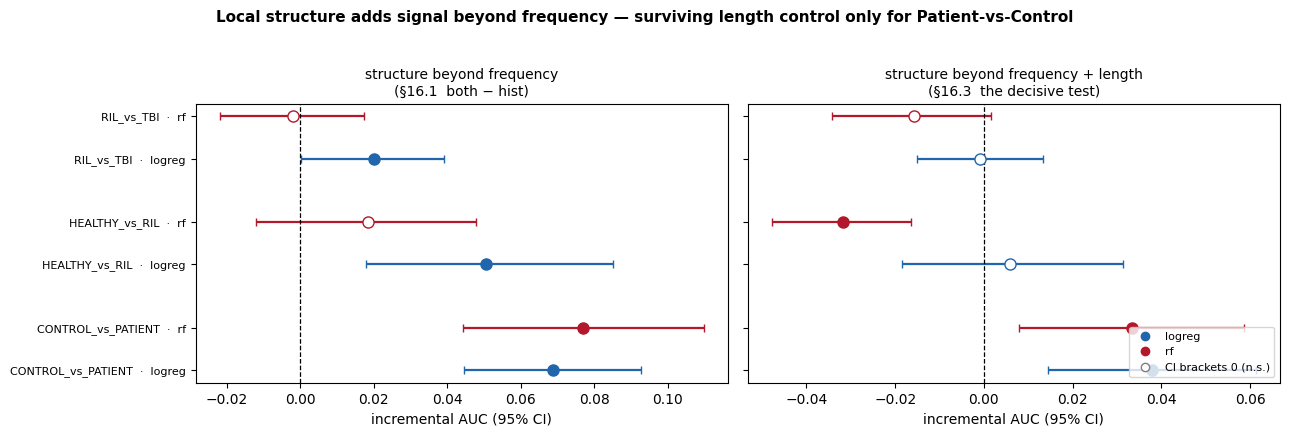

In [7]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

COMPS = ['CONTROL_vs_PATIENT', 'HEALTHY_vs_RIL', 'RIL_vs_TBI']
CLFS = ['logreg', 'rf']
clf_color = {'logreg': '#2166ac', 'rf': '#b2182b'}
panels = [
    (inc, 'mean_delta', 'delta_ci_low', 'delta_ci_high',
     'structure beyond frequency\n(§16.1  both − hist)'),
    (lc, 'delta_struct_given_len', 'delta_struct_given_len_ci_low',
     'delta_struct_given_len_ci_high',
     'structure beyond frequency + length\n(§16.3  the decisive test)'),
]
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4), sharey=True)
for ax, (data, dcol, locol, hicol, title) in zip(axes, panels):
    yticks, ylabels, y = [], [], 0
    for comp in COMPS:
        for clf in CLFS:
            row = data[(data['comparison'] == comp) & (data['classifier'] == clf)]
            if not row.empty:
                d, lo, hi = row[dcol].iloc[0], row[locol].iloc[0], row[hicol].iloc[0]
                sig = (lo > 0) or (hi < 0)
                ax.errorbar(d, y, xerr=[[d - lo], [hi - d]], fmt='o', color=clf_color[clf],
                            mfc=clf_color[clf] if sig else 'white', mec=clf_color[clf],
                            capsize=3, lw=1.6, ms=8)
                yticks.append(y); ylabels.append(f'{comp}  ·  {clf}')
            y += 1
        y += 0.5
    ax.axvline(0, color='k', lw=0.9, ls='--')
    ax.set_yticks(yticks); ax.set_yticklabels(ylabels, fontsize=8)
    ax.set_xlabel('incremental AUC (95% CI)'); ax.set_title(title, fontsize=10)
    ax.invert_yaxis()
handles = [Line2D([0], [0], marker='o', color=clf_color[c], lw=0, label=c) for c in CLFS]
handles.append(Line2D([0], [0], marker='o', color='gray', mfc='white', lw=0,
                      label='CI brackets 0 (n.s.)'))
axes[1].legend(handles=handles, fontsize=8, loc='lower right')
fig.suptitle('Local structure adds signal beyond frequency — surviving length control only '
             'for Patient-vs-Control', fontsize=11, weight='bold')
fig.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig(os.path.join(OUT, 'structure_incremental_auc.png'), dpi=130, bbox_inches='tight')
plt.show()

## Verdict (reproduces §16.4)

The deliverable is the **library**; the honest finding is a **length-robust positive for
local execution structure on Patient-vs-Control** — patients are more *fragmented* and drift
*less* across task phases — while HEALTHY-vs-RIL reduces to sequence duration and RIL-vs-TBI
is null. Orthogonal to §15 (global order): *frequency dominates global discrimination (E);
local execution structure is a separate, real axis on Patient-vs-Control (G).* Confirm the
four CSVs under `outputs/symbolic_barycenter/g28/structure/` match the §16 tables.